In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
# Загружаем данные
df = pd.read_csv('Churn_Modelling.csv')
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [2]:
# Удаляем ненужные колонки
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Проверяем, остались ли пропуски
print(df.isnull().sum())
# Смотрим на обновленную таблицу
df.head()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Подготовка данных
- Нет пропусков, Dtype соответствует
  Определим какой процент клиентов уже вышел?

In [3]:
df['Exited'].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

- Остались 79.6%, ушли - 20.4%

## Проверим показатель Age

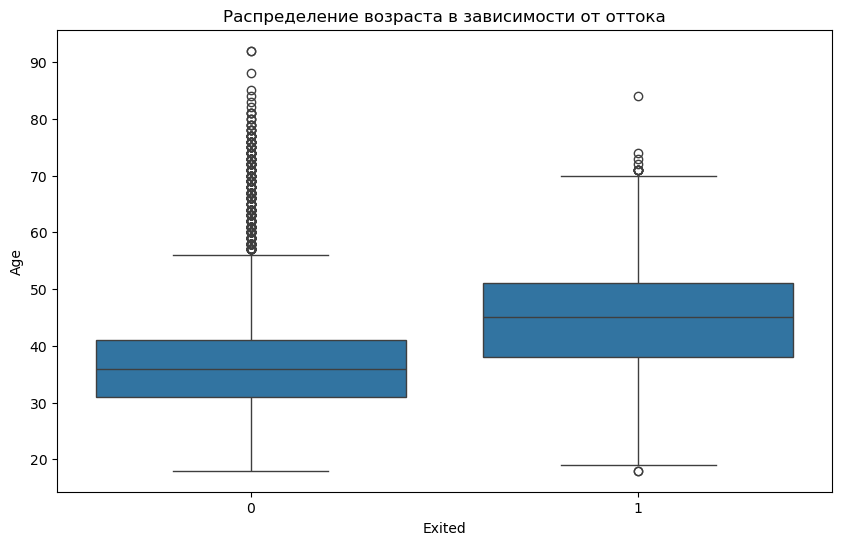

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Распределение возраста в зависимости от оттока')
plt.show()

## Наблюдения:
- Наблюдается заметная разница в возрастном распределении. Медианный возраст ушедших клиентов (45 лет) существенно выше, чем у лояльных клиентов (37 лет).
- Гипотеза: Риск оттока выше среди клиентов более зрелого возраста. Возможно, банковские продукты или условия обслуживания менее привлекательны для клиентов старшей возрастной группы. Либо клиенты этой возрастной группы чаще сталкиваются с проблемами в интерфейсе
- Рекомендация: Провести исследование потребностей клиентов возрастной категории 40+ лет

## Проверим финансовый показатель Balance

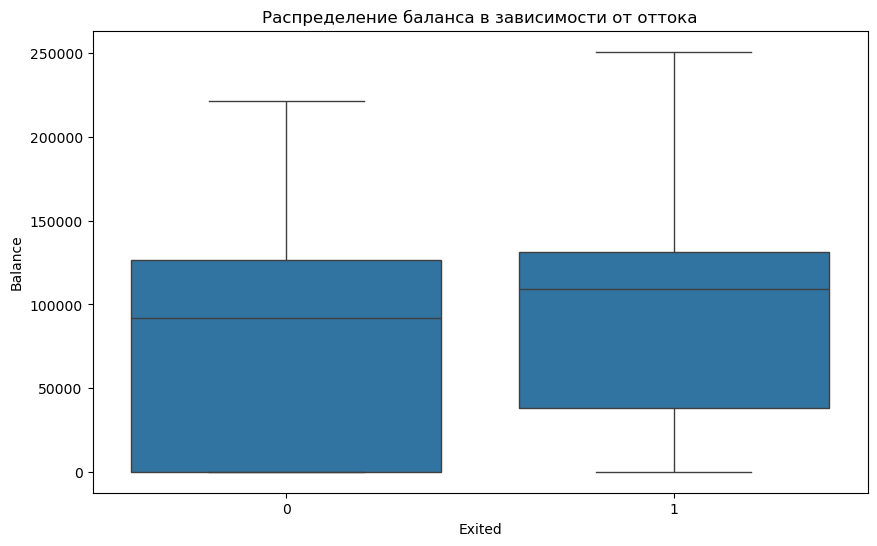

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited',y='Balance', data=df)
plt.title('Распределение баланса в зависимости от оттока')
plt.show()

## Наблюдение: 
- Ящик с усами лояльных (Exited = 0) клиентов прижат к нижней оси. В данных много пользователей с нулевым балансом.
- Медина баланса ушедших (Exited = 1) выше.
- Банк теряет "состоятельных" клиентов. Посмотрим распределение на гистограмме.

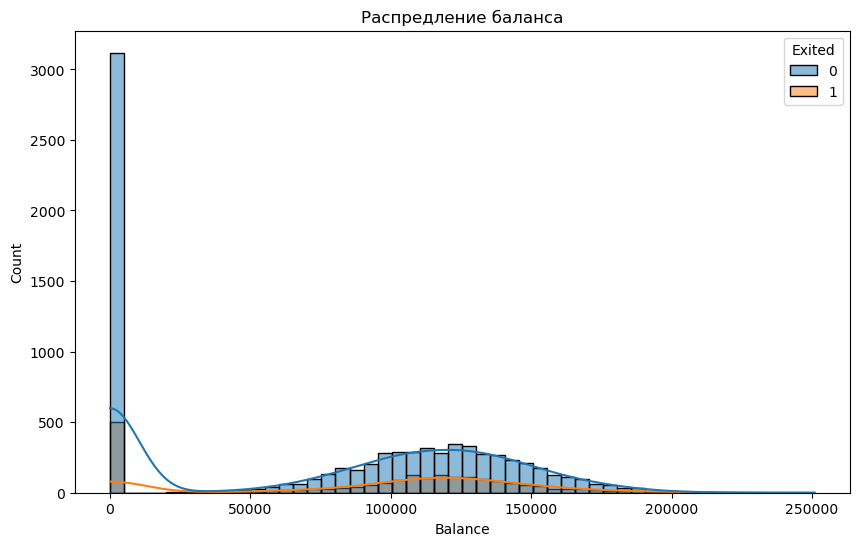

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df,x='Balance', hue='Exited', kde='True', bins=50)
plt.title('Распредление баланса')
plt.show()

## Наблюдение:
- Среди лояльных клиентов примерно в 6 раз больше пользователей с нулевыми балансами. Возможно используют карту для редких переводов, как зарплатный проект с переводом средств в другой банк или имеют только кредитные продукты.
- Ушедшие клиенты распределены более равномерно и часто имеют баланс 100000 - 150000.

## Влияет ли страна проживания на отток

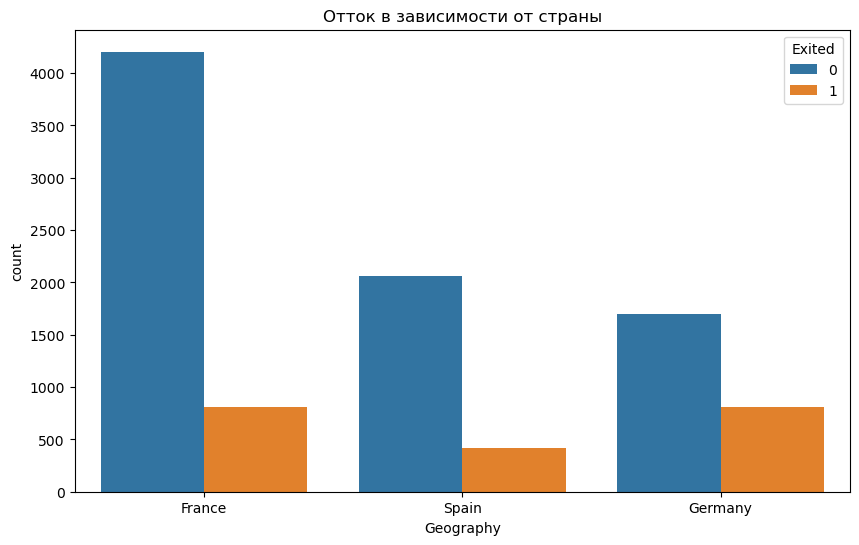

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Geography', hue='Exited', data=df)
plt.title('Отток в зависимости от страны')
plt.show()

In [8]:
# Считаем среднее значение Exited по странам
# 1 - это уход, а 0 - лояльность, среднее покажет долю ушедших
geography_churn = df.groupby('Geography')['Exited'].mean()
print(geography_churn)

Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64


## В Германии доля оттока в два раза выше, чем в других странах.

## Построим тепловую карту:
- Ближе к 1: прямая связь (чем больше одно, тем больше другое)
- Ближе к -1: обратная связь
- Около 0: связи почти нет

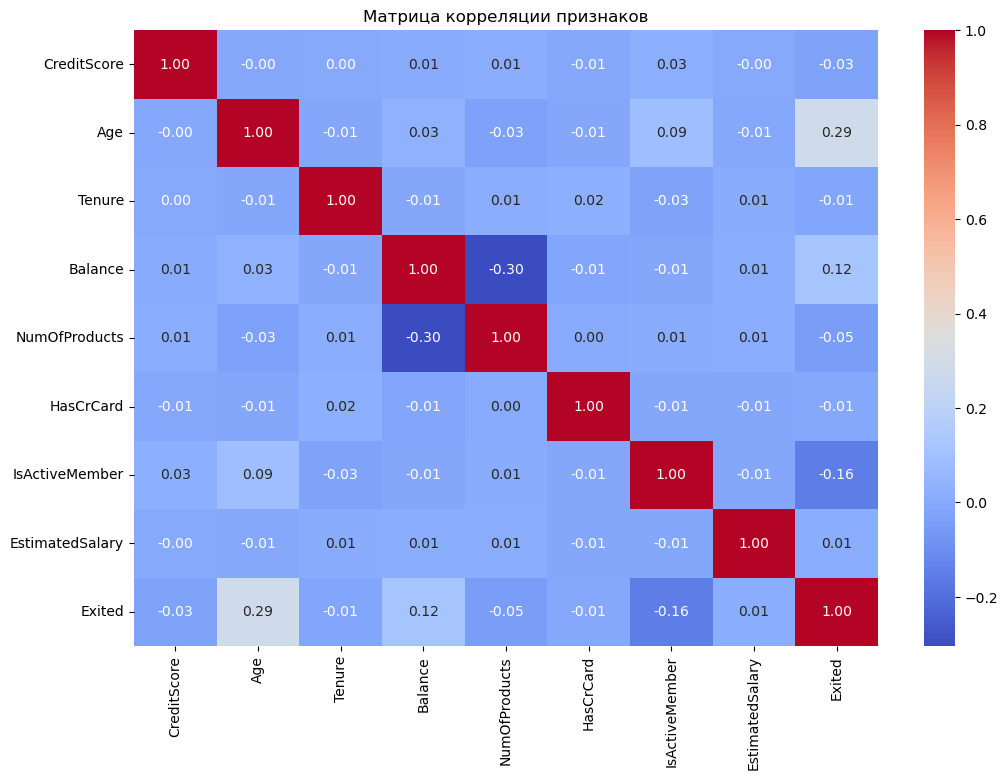

In [9]:
plt.figure(figsize=(12, 8))
# Выбираем только числовые колонки для корреляции
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции признаков')
plt.show()

## Наблюдения:
- Наибольшее влияние на прямую связь парметры Age (0.29) и Balance (0.12)
- Чем выше возраст, тем выше вероятность ухода

In [10]:
# Превращаем категориальные признаки в числовые
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# Посмотрим, как теперь выглядит таблица
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


# Подготовка к моделированию
## Разделим датасет
- X - матрица признаков
- y - вектор целевой переменной

In [11]:
# Признаки (все, кроме колонки Exited)
X = df.drop('Exited', axis=1)

# Целевая переменная
y = df['Exited']

In [12]:
from sklearn.model_selection import train_test_split

# X — признаки, y — таргет
X = df.drop('Exited', axis=1)
y = df['Exited']

# Разделяем на 80% для обучения и 20% для теста
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# (42 - магическое число для воспроизводимости, может быть любым)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (8000, 11)
Размер тестовой выборки: (2000, 11)


In [13]:
from sklearn.ensemble import RandomForestClassifier

# Создаем модель
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Обучаем модель на наших тренировочных данных
model.fit(X_train, y_train)
print('Модель успешно обучена')


Модель успешно обучена


In [14]:
from sklearn.metrics import accuracy_score

# 1. Делаем предсказания
y_pred = model.predict(X_test)

# 2. Считаем общую точность
accuracy = accuracy_score(y_test, y_pred)
print(f"Общая точность модели (Accuracy): {accuracy:.2%}")


Общая точность модели (Accuracy): 86.65%


## Проверим матрицу ошибок:

In [15]:
from sklearn.metrics import classification_report

# Печатаем детальную таблицу метрик
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



## Результаты моделирования:
- Поиск лояльных клиентов Recall 0.96 - модель безошибочно узнает 96% калиентов, которые не собираются уходить
- Поиск уходящих клиентов Recall 0.47 - модель находит меньше половины реальных уходящих клиентов. 53% потенциальных потерь модель классифицирует как лояльных
- Точность предсказания оттока 0.76 - модель предсказывает уход и права в 76% случаев
- Модель требует доработки

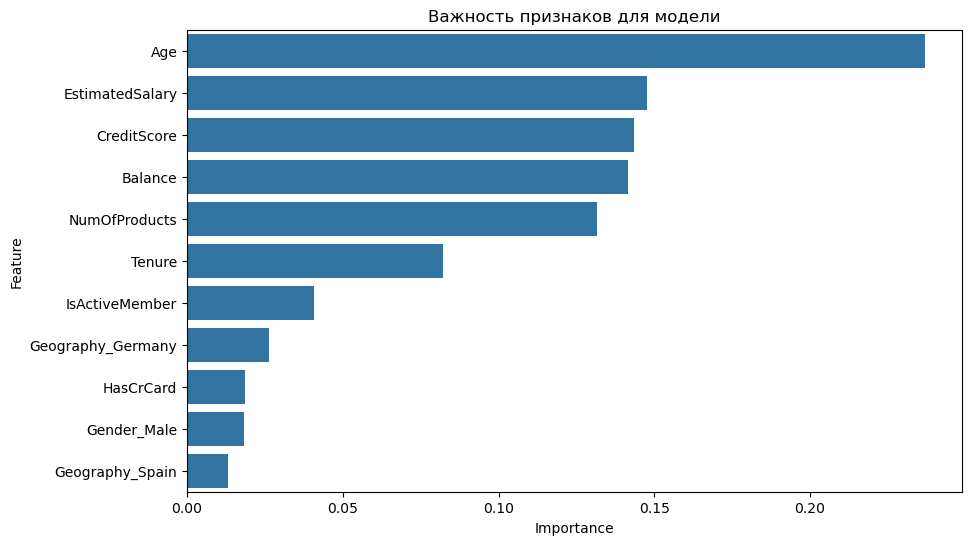

In [16]:
# Достаем важность признаков из нашей модели
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Строим график
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Важность признаков для модели')
plt.show()


# Итоговые выводы по проекту:
    
- Главный фактор оттока — возраст: Клиенты старшей возрастной группы (40-55 лет) уходят значительно чаще, чем молодые. Модель подтвердила, что Age — самый важный признак для прогноза.
- Географический риск: Уровень оттока в Германии (32.4%) в два раза выше, чем во Франции (16.1%) и Испании (16.6%). Это критическая точка для бизнеса.
- Продукт и активность: Наличие кредитной карты почти не влияет на лояльность, зато статус активного члена банка (IsActiveMember) заметно снижает риск ухода.
- Качество модели: Мы обучили модель с точностью 86.6%. Она отлично находит лояльных клиентов, но пока выявляет только 47% тех, кто реально собирается уйти.

# Бизнес-рекомендации:
- Удержание аудитории 40+: Разработать специальные пенсионные или накопительные программы, так как текущие условия для этой группы менее привлекательны.
- Аудит филиалов в Германии: Необходимо выяснить, почему немецкие клиенты уходят в два раза чаще. Возможно, там выше конкуренция или есть проблемы с качеством обслуживания.
- Повышение активности: Стимулировать клиентов чаще пользоваться приложением или услугами банка, так как активность напрямую коррелирует с лояльностью.